In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("solar_eolica_hidro_horario_2024.csv", index_col="datetime", parse_dates=["datetime"])
df

,solar_mw_real,eolica_mw_real,hidro_mw_real
datetime,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698
2024-01-01 02:00:00,0.0,123.2682,427.5446
2024-01-01 03:00:00,0.0,170.8097,337.3828
2024-01-01 04:00:00,0.0,95.7732,411.8209
2024-01-01 05:00:00,0.0,101.6279,383.3069
...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103
2024-12-31 21:00:00,0.0,77.8649,760.3992
2024-12-31 22:00:00,0.0,35.3924,729.7733


In [3]:
df2 = pd.read_csv("DEM2024.csv", skiprows=2, thousands=",")
df2 = df2.rename(columns={"Unnamed: 0": "Date"})
df2["Date"] = pd.to_datetime(df2["Date"], errors="coerce")
df2 = df2.dropna(subset=["Date"])

df2 = df2.melt(id_vars="Date", var_name="Hour", value_name="Demand MW")
df2["datetime"] = df2["Date"] + pd.to_timedelta(df2["Hour"].str[1:].astype(int), unit="h")
demand = df2.set_index("datetime")[["Demand MW"]].sort_index()

In [4]:
merged = df.join(demand)
merged

,solar_mw_real,eolica_mw_real,hidro_mw_real,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


In [5]:
merged.rename ( {"solar_mw_real" : "Solar MW", 	"eolica_mw_real": "Wind MW", "hidro_mw_real": "Hydro MW"}, axis = 1, inplace = True)

In [6]:
merged

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


In [7]:
df = merged

In [8]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3
...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7


Text(0.5, 1.0, 'Hourly System Demand and Renewables Generation')

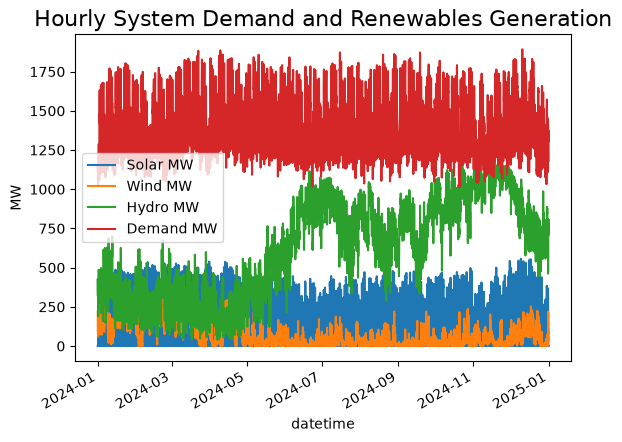

In [9]:
df.plot()

plt.ylabel("MW")
plt.title ("Hourly System Demand and Renewables Generation", fontsize=16)


In [10]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Net load MW"] = 0
    else:
        df.loc[k, "Net load MW"] = df.loc[k, "Demand MW"] - (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])

In [11]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW
datetime,,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6,593.1465
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0,596.1872
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0,624.8075
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8,599.2059
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3,605.3652
...,...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4,474.9147
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5,507.2359
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7,520.5343


Text(0.5, 1.0, 'Net Load')

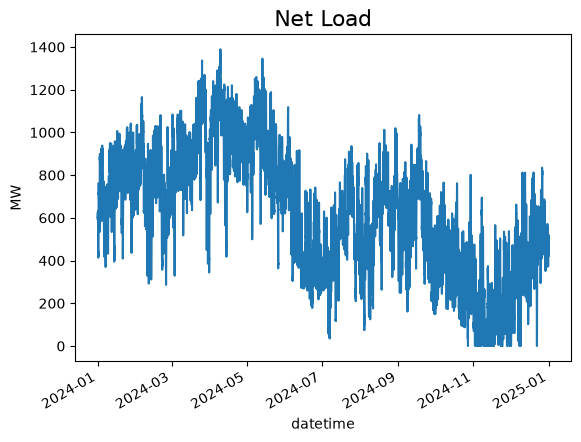

In [12]:
df["Net load MW"].plot()

plt.ylabel("MW")
plt.title ("Net Load", fontsize=16)

Text(0.5, 1.0, 'Net Load')

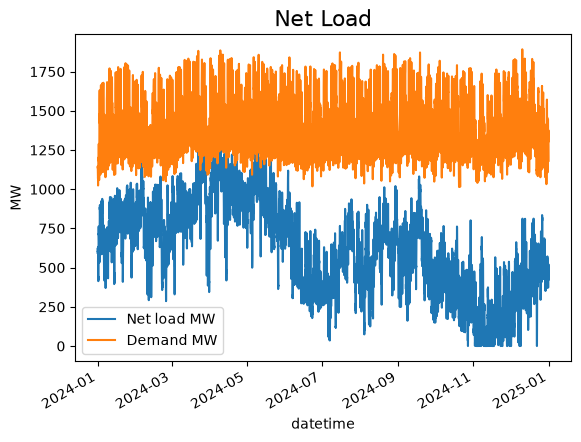

In [13]:
df[["Net load MW", "Demand MW"]].plot()

plt.ylabel("MW")
plt.title ("Net Load", fontsize=16)

In [14]:
check = df[ "Net load MW"] > df[ "Demand MW"]
check

datetime
2024-01-01 01:00:00    False
2024-01-01 02:00:00    False
2024-01-01 03:00:00    False
2024-01-01 04:00:00    False
2024-01-01 05:00:00    False
                       ...  
2024-12-31 20:00:00    False
2024-12-31 21:00:00    False
2024-12-31 22:00:00    False
2024-12-31 23:00:00    False
2025-01-01 00:00:00    False
Length: 8736, dtype: bool

In [15]:
sum(check)


0

In [16]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Renewables Share %"] = 100
    else:
        df.loc[k, "Renewables Share %"] =  (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])/ df.loc[k, "Demand MW"]*100

In [17]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW,Renewables Share %
datetime,,,,,,
2024-01-01 01:00:00,0.0,219.7837,326.6698,1139.6,593.1465,47.951343
2024-01-01 02:00:00,0.0,123.2682,427.5446,1147.0,596.1872,48.022040
2024-01-01 03:00:00,0.0,170.8097,337.3828,1133.0,624.8075,44.853707
2024-01-01 04:00:00,0.0,95.7732,411.8209,1106.8,599.2059,45.861411
2024-01-01 05:00:00,0.0,101.6279,383.3069,1090.3,605.3652,44.477190
...,...,...,...,...,...,...
2024-12-31 20:00:00,0.0,89.0750,809.4103,1373.4,474.9147,65.420511
2024-12-31 21:00:00,0.0,77.8649,760.3992,1345.5,507.2359,62.301308
2024-12-31 22:00:00,0.0,35.3924,729.7733,1285.7,520.5343,59.513549


Text(0.5, 1.0, ' Annual Renewable Contribuiton to Meet hourly Demand %')

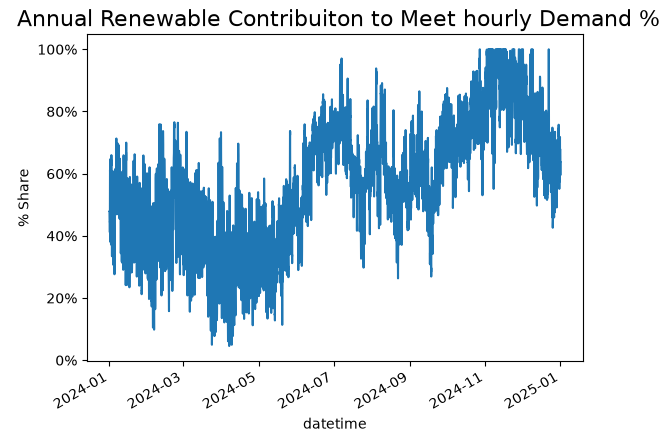

In [18]:
fig, ax = plt.subplots()
ax = df["Renewables Share %"].plot()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylabel("% Share")
plt.title(" Annual Renewable Contribuiton to Meet hourly Demand %", fontsize=16)

# LOAD DURATION CURVE

In [19]:
df_electricity_demand = df[["Demand MW"]]

In [20]:
df_electricity_demand.sort_values( by = "Demand MW", ascending = False, inplace = True)

In [21]:
df_electricity_demand.index = np.arange (1, 8737)
df_electricity_demand


,Demand MW
1,1892.3
2,1885.3
3,1882.4
4,1880.5
5,1875.1
...,...
8732,1032.4
8733,1023.8
8734,1018.1
8735,1015.7


Text(0.5, 0, 'Hours')

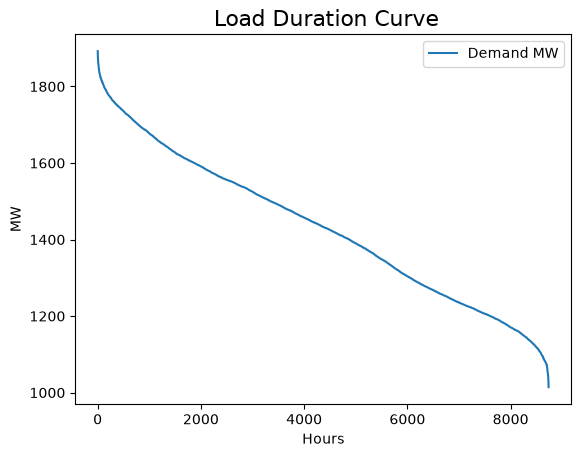

In [22]:
df_electricity_demand.plot()
plt.title(" Load Duration Curve", fontsize=16)
plt.ylabel("MW")
plt.xlabel("Hours")

# RESIDUAL LOAD DURATION CURVE

In [23]:
df["residual load MW"] = df["Demand MW"] - (df[ "Wind MW"] + df["Hydro MW"] + df["Solar MW"])
df[["residual load MW"]]

,residual load MW
datetime,
2024-01-01 01:00:00,593.1465
2024-01-01 02:00:00,596.1872
2024-01-01 03:00:00,624.8075
2024-01-01 04:00:00,599.2059
2024-01-01 05:00:00,605.3652
...,...
2024-12-31 20:00:00,474.9147
2024-12-31 21:00:00,507.2359
2024-12-31 22:00:00,520.5343


In [24]:
df_residual_demand =  df[["residual load MW"]]

In [25]:
df_residual_demand.sort_values( by = "residual load MW", ascending = False, inplace = True)
df_residual_demand.index = np.arange(1,8737)


<Axes: >

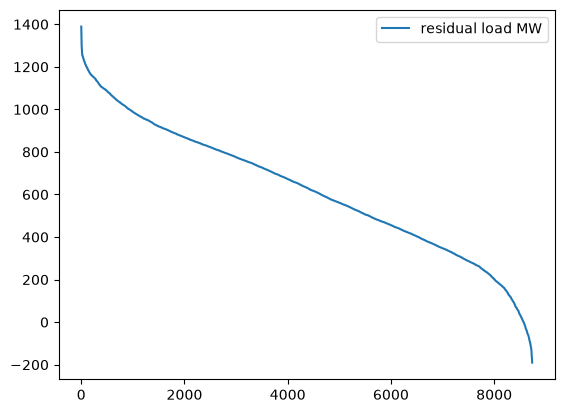

In [26]:
df_residual_demand.plot()

<Axes: >

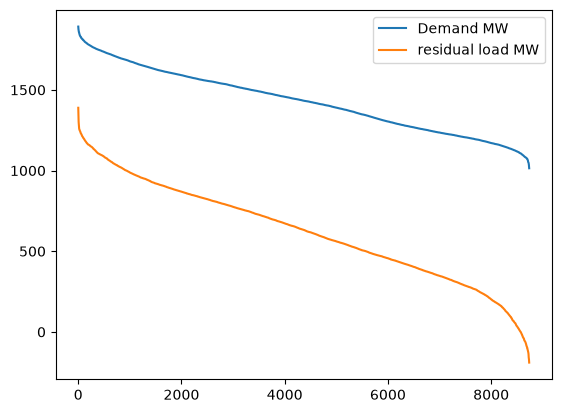

In [27]:
fig, ax = plt.subplots()
df_electricity_demand.plot(ax = ax)
df_residual_demand.plot(ax = ax)

In [28]:
df_demand = df_electricity_demand.join(df_residual_demand)
df_demand

,Demand MW,residual load MW
1,1892.3,1389.1089
2,1885.3,1371.8909
3,1882.4,1345.1961
4,1880.5,1336.5841
5,1875.1,1330.9542
...,...,...
8732,1032.4,-170.6904
8733,1023.8,-174.3137
8734,1018.1,-177.2525
8735,1015.7,-179.2269


In [29]:
df_demand[ "Load_Met_By_Renewables"] = df_demand[ "Demand MW"] - df_demand["residual load MW"]


In [30]:
df_demand

,Demand MW,residual load MW,Load_Met_By_Renewables
1,1892.3,1389.1089,503.1911
2,1885.3,1371.8909,513.4091
3,1882.4,1345.1961,537.2039
4,1880.5,1336.5841,543.9159
5,1875.1,1330.9542,544.1458
...,...,...,...
8732,1032.4,-170.6904,1203.0904
8733,1023.8,-174.3137,1198.1137
8734,1018.1,-177.2525,1195.3525
8735,1015.7,-179.2269,1194.9269


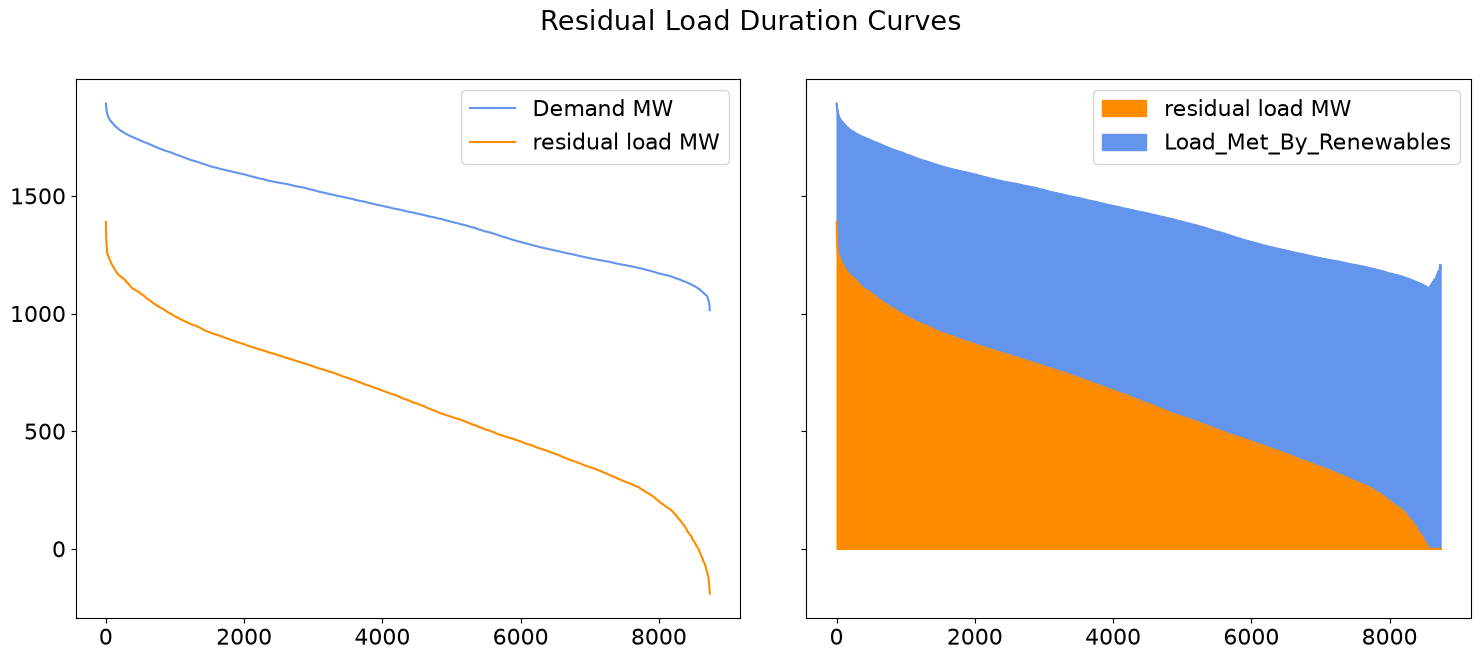

In [31]:
plt.rcParams["font.size"] = 16
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,7), sharey=True)
plt.subplots_adjust(wspace=0.1)
fig.suptitle("Residual Load Duration Curves")

df_demand[["Demand MW", "residual load MW"]].plot(ax=ax1, color=["cornflowerblue", "darkorange"])
df_demand[["residual load MW", "Load_Met_By_Renewables"]].clip(lower=0).plot(ax=ax2, color=[ "darkorange", "cornflowerblue"], kind="area", stacked=True)
plt.show()

In [32]:
df_demand["base_load"]= df_demand["Demand MW"].min()

df_demand

,Demand MW,residual load MW,Load_Met_By_Renewables,base_load
1,1892.3,1389.1089,503.1911,1014.3
2,1885.3,1371.8909,513.4091,1014.3
3,1882.4,1345.1961,537.2039,1014.3
4,1880.5,1336.5841,543.9159,1014.3
5,1875.1,1330.9542,544.1458,1014.3
...,...,...,...,...
8732,1032.4,-170.6904,1203.0904,1014.3
8733,1023.8,-174.3137,1198.1137,1014.3
8734,1018.1,-177.2525,1195.3525,1014.3
8735,1015.7,-179.2269,1194.9269,1014.3


In [33]:
df_demand["intermediate + peak load"] = df_demand["Demand MW"] - df_demand["base_load"]
df_demand

,Demand MW,residual load MW,Load_Met_By_Renewables,base_load,intermediate + peak load
1,1892.3,1389.1089,503.1911,1014.3,878.0
2,1885.3,1371.8909,513.4091,1014.3,871.0
3,1882.4,1345.1961,537.2039,1014.3,868.1
4,1880.5,1336.5841,543.9159,1014.3,866.2
5,1875.1,1330.9542,544.1458,1014.3,860.8
...,...,...,...,...,...
8732,1032.4,-170.6904,1203.0904,1014.3,18.1
8733,1023.8,-174.3137,1198.1137,1014.3,9.5
8734,1018.1,-177.2525,1195.3525,1014.3,3.8
8735,1015.7,-179.2269,1194.9269,1014.3,1.4


In [34]:
df_demand["Demand MW"].min()

np.float64(1014.3)

In [35]:
df_demand["Demand MW"].max()

np.float64(1892.3)

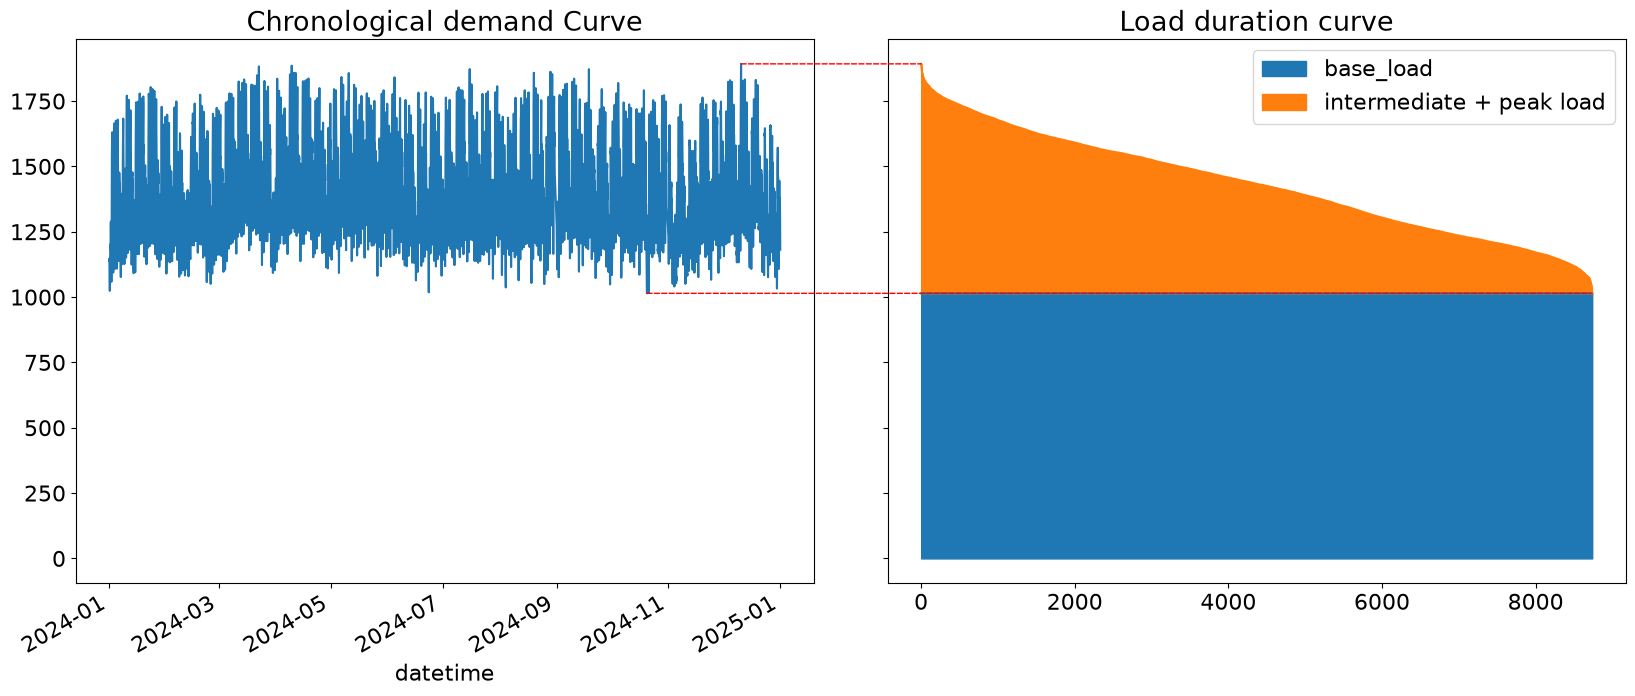

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2,
                               figsize = (20, 8),
                               sharey = True)
plt.subplots_adjust(wspace = 0.1)

df["Demand MW"].plot(ax = ax1)
ax1.set_title("Chronological demand Curve")

df_demand[["base_load","intermediate + peak load"]].plot(ax = ax2,
                                                  kind = "area",
                                                  stacked = True,
                                                  )
ax2.set_title("Load duration curve")

from matplotlib.patches import ConnectionPatch
import matplotlib.dates as mdates

peak_time = df["Demand MW"].idxmax()
peak_value = df["Demand MW"].max()

con = ConnectionPatch(
    xyA = (mdates.date2num(peak_time), peak_value), coordsA = ax1.transData,
    xyB = (1, peak_value), coordsB = ax2.transData,
    color = "red", linestyle = "--"
)
fig.add_artist(con)

trough_time = df["Demand MW"].idxmin()
trough_value = df["Demand MW"].min()

con2 = ConnectionPatch(
    xyA = (mdates.date2num(trough_time), trough_value), coordsA = ax1.transData,
    xyB = (df_demand.index.max(), trough_value), coordsB = ax2.transData,
    color = "red", linestyle = "--"
)
fig.add_artist(con2)